## Business Understanding

### 1. What is the main business problem?

The main business problem faced by UrbanFleet Logistics is predicting which delivery orders are at high risk of being delivered late before they are dispatched. Late deliveries can reduce customer satisfaction, increase refund and support costs, and damage the company's reputation. The business wants to use machine learning to identify risky orders early so that managers can take proactive actions to improve delivery performance.

### 2. Why is customer/user segmentation useful for this business?

Customer segmentation is useful because different customer groups may have different delivery patterns, expectations, and risk levels. For example, retail customers, corporate clients, and marketplace sellers may place different types of orders and require different service levels. By identifying customer segments, UrbanFleet can better understand which groups are more likely to experience delivery delays and tailor its operational strategies accordingly. Segmentation can also help allocate resources more efficiently and improve customer satisfaction.

### 3. What kind of marketing decisions could be improved by discovering customer/user groups?

Discovering customer groups can help UrbanFleet make more effective marketing and customer relationship decisions. For example:

- Offer premium delivery services to customer segments that value fast and reliable delivery.
- Create targeted promotions for high-value customers.
- Develop loyalty programs for customers who frequently use delivery services.
- Improve communication strategies by sending personalized updates to customers with a higher risk of delays.
- Focus marketing efforts on customer groups that generate the most revenue or have the highest retention potential.

By understanding different customer segments, UrbanFleet can provide more personalized services, improve customer satisfaction, and increase business growth.

In [2]:
import pandas as pd 
df = pd.read_excel("urbanfleet_delivery_delay_risk_dataset.xlsx")

In [4]:
df.head()

,Order_ID,Order_Date,Customer_Type,Delivery_Region,Product_Category,Order_Value_USD,Package_Weight_Kg,Distance_Km,Warehouse_Load_Level,Driver_Experience_Years,Weather_Condition,Traffic_Level,Delivery_Window_Hours,Priority_Shipping,Previous_Delays_For_Customer,Dispatch_Hour,Weekend_Order,Late_Delivery_Risk
0,UF-0001,2026-03-27,Corporate Client,University District,Health & Beauty,322.36,1.4,10.9,Medium,4.9,Clear,Medium,1,No,0,16,No,No
1,UF-0002,2026-01-07,Corporate Client,Suburban East,Electronics,46.66,2.1,11.0,Low,2.4,Rain,High,3,No,0,18,No,Yes
2,UF-0003,2026-02-05,Small Business,Suburban North,Electronics,28.02,2.2,19.5,Medium,6.5,Fog,High,1,No,0,19,No,Yes
3,UF-0004,2026-01-26,Marketplace Seller,Industrial Zone,Home Goods,84.31,1.3,29.3,Low,4.2,Clear,Medium,3,Yes,0,17,No,No
4,UF-0005,2026-01-08,Small Business,Downtown,Food & Beverage,80.01,4.7,7.4,Medium,5.5,Clear,High,2,No,3,16,No,No


In [8]:
df.shape

(360, 18)

In [10]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Type', 'Delivery_Region',
       'Product_Category', 'Order_Value_USD', 'Package_Weight_Kg',
       'Distance_Km', 'Warehouse_Load_Level', 'Driver_Experience_Years',
       'Weather_Condition', 'Traffic_Level', 'Delivery_Window_Hours',
       'Priority_Shipping', 'Previous_Delays_For_Customer', 'Dispatch_Hour',
       'Weekend_Order', 'Late_Delivery_Risk'],
      dtype='object')

In [12]:
df.dtypes

Order_ID                                object
Order_Date                      datetime64[ns]
Customer_Type                           object
Delivery_Region                         object
Product_Category                        object
Order_Value_USD                        float64
Package_Weight_Kg                      float64
Distance_Km                            float64
Warehouse_Load_Level                    object
Driver_Experience_Years                float64
Weather_Condition                       object
Traffic_Level                           object
Delivery_Window_Hours                    int64
Priority_Shipping                       object
Previous_Delays_For_Customer             int64
Dispatch_Hour                            int64
Weekend_Order                           object
Late_Delivery_Risk                      object
dtype: object

In [38]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Order_ID                        0
Order_Date                      0
Customer_Type                   0
Delivery_Region                 0
Product_Category                0
Order_Value_USD                 0
Package_Weight_Kg               0
Distance_Km                     0
Warehouse_Load_Level            0
Driver_Experience_Years         5
Weather_Condition               8
Traffic_Level                   4
Delivery_Window_Hours           0
Priority_Shipping               0
Previous_Delays_For_Customer    0
Dispatch_Hour                   0
Weekend_Order                   0
Late_Delivery_Risk              0
dtype: int64


In [28]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [40]:
# Select numerical features for clustering
numerical_features = [
    'Order_Value_USD',
    'Distance_Km',
    'Dispatch_Hour',
    'Delivery_Window_Hours',
    'Previous_Delays_For_Customer',
    'Driver_Experience_Years'
]

In [42]:
# Fill numerical missing values with the median
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

In [44]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Order_ID                        0
Order_Date                      0
Customer_Type                   0
Delivery_Region                 0
Product_Category                0
Order_Value_USD                 0
Package_Weight_Kg               0
Distance_Km                     0
Warehouse_Load_Level            0
Driver_Experience_Years         0
Weather_Condition               8
Traffic_Level                   4
Delivery_Window_Hours           0
Priority_Shipping               0
Previous_Delays_For_Customer    0
Dispatch_Hour                   0
Weekend_Order                   0
Late_Delivery_Risk              0
dtype: int64


In [46]:
Cat_features = df.select_dtypes(include=['object']).columns
Cat_features

Index(['Order_ID', 'Customer_Type', 'Delivery_Region', 'Product_Category',
       'Warehouse_Load_Level', 'Weather_Condition', 'Traffic_Level',
       'Priority_Shipping', 'Weekend_Order', 'Late_Delivery_Risk'],
      dtype='object')

In [50]:
#Fill categorical missing values with the mode 
for col in Cat_features:
    df[col] = df[col].fillna(df[col].mode()[0])

In [52]:
null_values = df.isnull().sum()
print("Sum of null values for each column:\n", null_values)

Sum of null values for each column:
 Order_ID                        0
Order_Date                      0
Customer_Type                   0
Delivery_Region                 0
Product_Category                0
Order_Value_USD                 0
Package_Weight_Kg               0
Distance_Km                     0
Warehouse_Load_Level            0
Driver_Experience_Years         0
Weather_Condition               0
Traffic_Level                   0
Delivery_Window_Hours           0
Priority_Shipping               0
Previous_Delays_For_Customer    0
Dispatch_Hour                   0
Weekend_Order                   0
Late_Delivery_Risk              0
dtype: int64


In [54]:
# Features for clustering 
X = df[numerical_features]

In [56]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
import pandas as pd

X_scaled = pd.DataFrame(
    X_scaled,
    columns=numerical_features
)

X_scaled.head()

,Order_Value_USD,Distance_Km,Dispatch_Hour,Delivery_Window_Hours,Previous_Delays_For_Customer,Driver_Experience_Years
0,3.753562,-0.464519,0.692276,-1.331593,-0.867560,0.005675
1,-0.827140,-0.454485,1.302360,-0.183393,-0.867560,-1.080977
2,-1.136840,0.398406,1.607401,-1.331593,-0.867560,0.701132
3,-0.201592,1.381739,0.997318,-0.183393,-0.867560,-0.298588
4,-0.273036,-0.815709,0.692276,-0.757493,1.864115,0.266471


C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

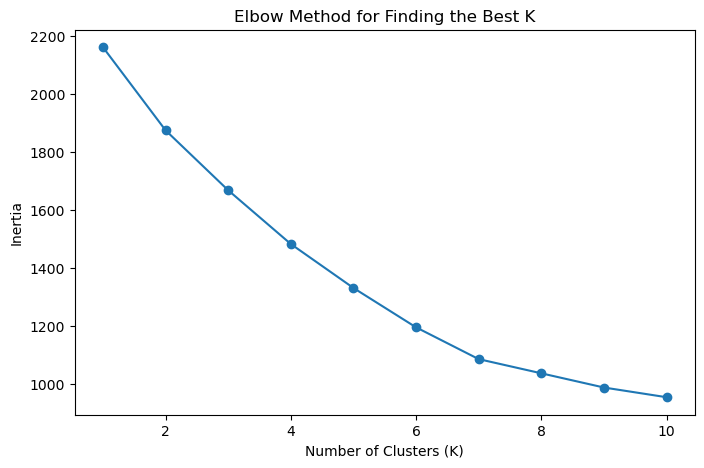

In [58]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()

In [75]:
# Display inertia values for each K

elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,2160.000000
1,2,1873.366868
2,3,1666.603967
3,4,1481.282287
4,5,1329.666310
5,6,1193.913504
6,7,1084.272496
7,8,1035.350244
8,9,986.356105
9,10,952.911592


## Selecting the Number of Clusters

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering. The method evaluates the Within-Cluster Sum of Squares (WCSS), also known as inertia, for different values of K.

Based on the elbow plot, the decrease in inertia becomes less significant after approximately **7 clusters**. This indicates that adding more clusters beyond this point provides only limited improvement in cluster compactness.

Therefore, **K = 7** was selected as the optimal number of clusters because it provides a reasonable balance between cluster quality and model complexity.

## Training the Final K-Means Model

A K-Means clustering model was trained using **7 clusters** and the scaled numerical features:

- Order_Value_USD
- Distance_Km
- Dispatch_Hour
- Delivery_Window_Hours
- Previous_Delays_For_Customer
- Driver_Experience_Years

The resulting cluster labels were added back to the dataset to enable further analysis and interpretation of the identified customer and operational groups.

In [77]:

# Create the K-means model with 3 clusters
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

# Train the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]


C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([6, 0, 0, 3, 5, 4, 1, 0, 0, 2])

In [79]:
pd.Series(cluster_labels).value_counts().sort_index()

0    74
1    69
2    53
3    42
4    45
5    50
6    27
Name: count, dtype: int64

In [83]:
# Create a copy of the cleaned dataset
df_clustered = df.copy()

# Add cluster labels to the dataset
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

,Order_ID,Order_Date,Customer_Type,Delivery_Region,Product_Category,Order_Value_USD,Package_Weight_Kg,Distance_Km,Warehouse_Load_Level,Driver_Experience_Years,Weather_Condition,Traffic_Level,Delivery_Window_Hours,Priority_Shipping,Previous_Delays_For_Customer,Dispatch_Hour,Weekend_Order,Late_Delivery_Risk,Cluster
0,UF-0001,2026-03-27,Corporate Client,University District,Health & Beauty,322.36,1.4,10.9,Medium,4.9,Clear,Medium,1,No,0,16,No,No,6
1,UF-0002,2026-01-07,Corporate Client,Suburban East,Electronics,46.66,2.1,11.0,Low,2.4,Rain,High,3,No,0,18,No,Yes,0
2,UF-0003,2026-02-05,Small Business,Suburban North,Electronics,28.02,2.2,19.5,Medium,6.5,Fog,High,1,No,0,19,No,Yes,0
3,UF-0004,2026-01-26,Marketplace Seller,Industrial Zone,Home Goods,84.31,1.3,29.3,Low,4.2,Clear,Medium,3,Yes,0,17,No,No,3
4,UF-0005,2026-01-08,Small Business,Downtown,Food & Beverage,80.01,4.7,7.4,Medium,5.5,Clear,High,2,No,3,16,No,No,5


In [85]:
# Check how many customers are in each cluster

df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    74
1    69
2    53
3    42
4    45
5    50
6    27
Name: count, dtype: int64

In [87]:
cluster_summary = df.groupby('Cluster')[[
    'Order_Value_USD',
    'Distance_Km',
    'Dispatch_Hour',
    'Delivery_Window_Hours',
    'Previous_Delays_For_Customer',
    'Driver_Experience_Years'
]].mean().round(2)

cluster_summary

,Order_Value_USD,Distance_Km,Dispatch_Hour,Delivery_Window_Hours,Previous_Delays_For_Customer,Driver_Experience_Years
Cluster,,,,,,
0,79.37,12.10,17.11,2.53,0.53,4.21
1,78.58,11.44,10.67,2.91,0.57,3.25
2,83.73,10.25,13.26,2.51,0.98,8.23
3,81.28,33.67,13.14,2.95,0.45,5.09
4,77.92,13.42,13.33,6.71,0.93,4.76
5,105.83,18.28,14.10,2.88,2.82,4.08
6,250.92,15.94,14.11,3.85,0.41,5.74


## Cluster Analysis

### How many customer/user segments did you find?

Using the Elbow Method, K = 7 was selected as the optimal number of clusters. The K-Means model therefore identified **7 distinct customer/order segments**.

The cluster sizes were:

| Cluster | Number of Orders |
|----------|----------------|
| 0 | 74 |
| 1 | 69 |
| 2 | 53 |
| 3 | 42 |
| 4 | 45 |
| 5 | 50 |
| 6 | 27 |

### What are the main characteristics of each segment?

#### Cluster 0 – Afternoon Deliveries with Moderate Experience
- Moderate order value ($79.37)
- Medium delivery distance (12.10 km)
- Late-day dispatches (17:11 average)
- Moderate driver experience (4.21 years)
- Relatively low previous delays

This cluster represents standard delivery orders dispatched later in the day.

#### Cluster 1 – Morning Deliveries with Less Experienced Drivers
- Moderate order value ($78.58)
- Medium delivery distance (11.44 km)
- Morning dispatches (10:67 average)
- Lowest driver experience (3.25 years)

This segment appears to represent routine deliveries handled by less experienced drivers.

#### Cluster 2 – Experienced Driver Segment
- Moderate order value ($83.73)
- Shorter delivery distances (10.25 km)
- Highest driver experience (8.23 years)
- Moderate previous delays

This cluster benefits from highly experienced drivers and relatively short delivery routes.

#### Cluster 3 – Long-Distance Deliveries
- Moderate order value ($81.28)
- Longest delivery distance (33.67 km)
- Average driver experience (5.09 years)

This segment represents deliveries that travel significantly farther than other orders.

#### Cluster 4 – Flexible Delivery Window Segment
- Moderate order value ($77.92)
- Longest delivery window (6.71 hours)
- Higher previous delays (0.93)

These customers appear to accept more flexible delivery schedules.

#### Cluster 5 – High-Risk Operational Segment
- Higher order value ($105.83)
- High number of previous delays (2.82)
- Moderate driver experience (4.08 years)

This cluster contains customers or orders with a history of delivery issues and may require additional operational attention.

#### Cluster 6 – Premium Customer Segment
- Highest order value ($250.92)
- Relatively experienced drivers (5.74 years)
- Lowest previous delays (0.41)
- Smallest cluster (27 orders)

This segment contains the highest-value orders and appears to receive reliable service.

### How are the segments different from each other?

The clusters differ primarily in:

- Order value
- Delivery distance
- Delivery window length
- Previous delay history
- Driver experience

For example, Cluster 6 contains premium, high-value orders, while Cluster 3 contains long-distance deliveries. Cluster 2 is distinguished by highly experienced drivers, and Cluster 5 stands out because of its high number of previous delays.

### Which segment may be the most valuable for the business? Why?

**Cluster 6** appears to be the most valuable segment.

Reasons:
- Highest average order value ($250.92)
- Low history of delivery delays
- Experienced drivers
- Likely contributes the most revenue per order

Because these customers generate significantly higher revenue, maintaining excellent service for this segment should be a priority.

### Which segment may need more marketing attention? Why?

**Cluster 5** may require the most attention.

Reasons:
- Highest number of previous delays (2.82)
- Higher-value orders that could be lost if customers become dissatisfied
- Potential risk of customer churn due to service issues

UrbanFleet could focus on improving communication, offering proactive delivery updates, and providing service recovery incentives to retain customers in this segment.

## Business Recommendations

Based on the clustering results, UrbanFleet should:

1. Prioritize service quality for Cluster 6 to retain high-value customers.
2. Improve operational monitoring for Cluster 5 to reduce future delivery delays.
3. Develop specialized route-planning strategies for Cluster 3 due to long delivery distances.
4. Continue assigning experienced drivers to critical deliveries, as demonstrated by Cluster 2.
5. Use customer segmentation to tailor communication and operational decisions for different groups.

C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nafij\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

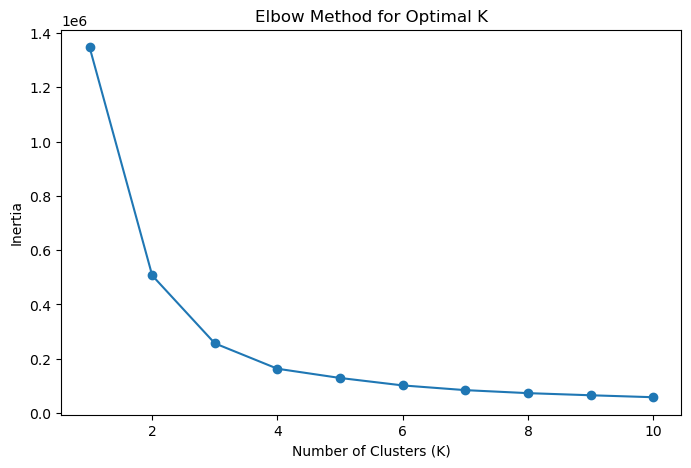

In [91]:
features = df[['Order_Value_USD', 'Distance_Km', 'Dispatch_Hour',
               'Delivery_Window_Hours', 'Previous_Delays_For_Customer',
               'Driver_Experience_Years']]

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

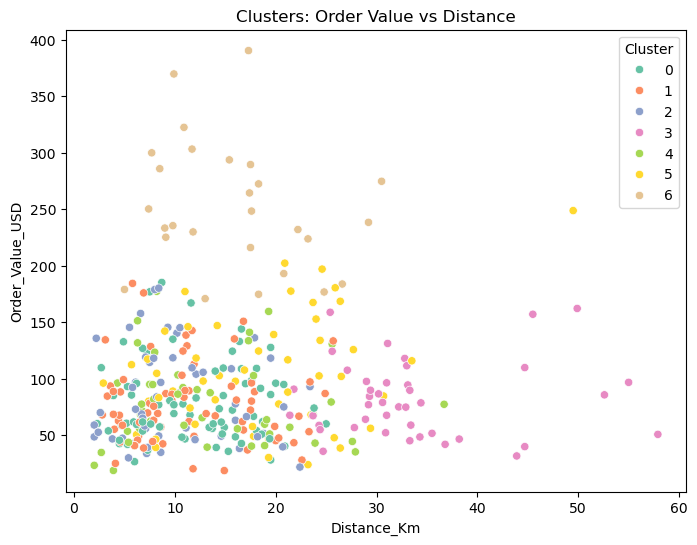

In [93]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x='Distance_Km',
                y='Order_Value_USD',
                hue='Cluster',
                palette='Set2')

plt.title("Clusters: Order Value vs Distance")
plt.show()

C:\Users\nafij\AppData\Local\Temp\ipykernel_52208\1010477084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Order_Value_USD', palette='Set3')


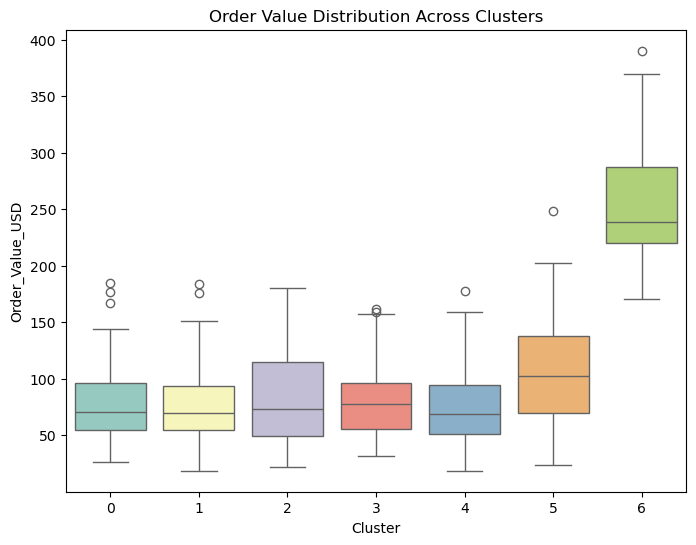

In [97]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Cluster', y='Order_Value_USD', palette='Set3')

plt.title("Order Value Distribution Across Clusters")
plt.show()